In [1]:
using DataFrames, JLD2, CSV, Dates, LinearAlgebra, Colors, Statistics, StatsBase, Distributions, Gadfly, HypothesisTests, Cairo, Fontconfig
include("/Users/asalazar1/Documents/MitriLab/Multilevel-selection/IND/IX/Codes/Colours.jl") ;

In [2]:
a = "/Users/asalazar1/Documents/MitriLab/Multilevel-selection/BGU/EXP1/Data/METACommunityPool_ManualR5.csv" 
METACom = CSV.read(a, DataFrame)
METACom.Members = [parse.(Int, split(METACom.Members[i], ", ")) for i in 1:length(METACom.Members)]
;

In [3]:
function mutation_distance(A, B)
    onlyA = length(setdiff(A, B))
    onlyB = length(setdiff(B, A))
    return max(onlyA, onlyB)
end

mutation_distance (generic function with 1 method)

In [4]:
n = length(METACom.Members)
D = Matrix{Int}(undef, n, n)
F = Matrix{Float64}(undef, n, n)

for i in eachindex(METACom.Members), j in eachindex(METACom.Members)
    D[i, j] = mutation_distance(METACom.Members[i], METACom.Members[j])
    F[i, j] = abs(METACom.CommunityScore[i] - METACom.CommunityScore[j])
end

In [5]:
n = nrow(METACom)

pairs = DataFrame(
    Community1 = [],
    Community2 = [],
    Fitness1 = Float64[],
    Fitness2 = Float64[],
    Distance = Int[],
    FitnessDifference = Float64[]
)

for i in 1:n
    for j in (i+1):n #No self relationship
        push!(pairs, (
            METACom.CommunityID[i],
            METACom.CommunityID[j],
            METACom.CommunityScore[i],
            METACom.CommunityScore[j],
            D[i, j],
            F[i, j]
        ))
    end
end

In [6]:
pairs

Row,Community1,Community2,Fitness1,Fitness2,Distance,FitnessDifference
,Any,Any,Float64,Float64,Int64,Float64
1,com1,com2,0.107539,0.122616,34,0.0150772
2,com1,com3,0.107539,0.175309,19,0.06777
3,com1,com4,0.107539,0.119891,12,0.0123524
4,com1,com5,0.107539,0.111026,26,0.00348764
5,com1,com6,0.107539,0.0943396,7,0.013199
6,com1,com7,0.107539,0.06469,9,0.0428486
7,com1,com8,0.107539,0.188679,14,0.0811406
8,com1,com9,0.107539,0.19407,29,0.0865315
9,com1,com10,0.107539,-4.41e-5,10,0.107583


In [7]:
pink6 = [colorant"#fff", pinks[end], pinks[end-3], pinks[1], pinks[2], pinks[4]]

neighbors = filter(:Distance => ==(1), pairs) ;
aliens = filter(:Distance => >=(20), pairs) ;

In [8]:
set_default_plot_size(30cm, 15cm)

#dis = plot(
#    pairs,
#    x = :Distance,
#    y = :FitnessDifference,
#    color = [colorant"#ED71AA"],
#    Geom.point,
#    size = [1.5mm],
#    alpha = [0.8],
#    Guide.xlabel("Mutation distance"),
#    Guide.ylabel("|Δ Community score|"),
#    Theme(highlight_width = 0.5pt, major_label_font_size = 15pt,
#            continuous_highlight_color = _ -> "white"))

#draw(PDF("DistanceFitness.pdf", 26cm, 16cm), dis)

In [9]:
mean(pairs.FitnessDifference)

0.10197891969031479

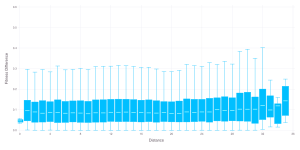

In [10]:
boxpair = plot(
    pairs,
    x = :Distance,
    y = :FitnessDifference,
    #color = [colorant"#ED71AA"],
    Geom.boxplot(suppress_outliers = true), 
    #Coord.cartesian(ymin = 0),
    Guide.xticks(ticks = collect(0:4:37)),
    Guide.xlabel("Distance"),
    Guide.ylabel("Fitness Difference")
)

#draw(PDF("BoxDistance.pdf", 40cm, 16cm), boxpair)

In [12]:
cor(pairs.FitnessDifference, pairs.Distance)

0.029629915288534772

In [11]:
neighbors.closestNeighbours = neighbors.FitnessDifference .< 0.01 ;

In [12]:
setdiff(METACom.Members[5], METACom.Members[68])
setdiff(METACom.Members[68], METACom.Members[5])

1-element Vector{Int64}:
 10

In [13]:
using DataFrames
using Statistics
using Random

# Mutation distances present in the data
dists = sort(unique(pairs.Distance))

nperm = 1000

# Matrix storing the mean score distance for each permutation
nullmeans = Matrix{Float64}(undef, length(dists), nperm)

for p in 1:nperm
    # Break the association by permuting the scores
    shuffled = shuffle(pairs.FitnessDifference)

    for (i, d) in enumerate(dists)
        idx = findall(pairs.Distance .== d)
        nullmeans[i, p] = mean(shuffled[idx])
    end
end

# Expected null mean and 95% envelope
nullmean = vec(mean(nullmeans, dims=2))
lower = [quantile(view(nullmeans,i,:), 0.025) for i in 1:length(dists)]
upper = [quantile(view(nullmeans,i,:), 0.975) for i in 1:length(dists)]

nulldf = DataFrame(
    MutationDistance = dists,
    Mean = nullmean,
    Lower = lower,
    Upper = upper
)

Row,MutationDistance,Mean,Lower,Upper
,Int64,Float64,Float64,Float64
1,0,0.102897,0.017376,0.227133
2,1,0.101892,0.0908702,0.112111
3,2,0.101813,0.0926118,0.110668
4,3,0.102142,0.0947962,0.110098
5,4,0.101863,0.0957518,0.108576
6,5,0.102002,0.09715,0.106854
7,6,0.101882,0.0984136,0.105338
8,7,0.102019,0.0991656,0.104791
9,8,0.102004,0.0996652,0.104284


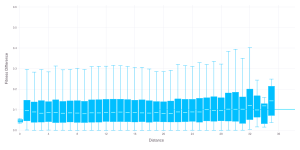

In [14]:
boxpair = plot(
    layer(pairs,
    x = :Distance,
    y = :FitnessDifference,
    Geom.boxplot(suppress_outliers = true), 
    ),
    
    layer(x = repeat([38], length(nulldf.Mean)),
    y = nulldf.Mean,
    Geom.boxplot(suppress_outliers = true), 
    ),

    Guide.xticks(ticks = collect(0:4:37)),
    Guide.xlabel("Distance"),
    Guide.ylabel("Fitness Difference")
)

In [15]:
disa = CSV.read("/Users/asalazar1/Downloads/Disassembly_Validation_Normalized_FD_Results.csv", DataFrame)

Row,Well,Plate_Name,Plate,Sampling,Tech_Rep,FD,CommunityID_Name,CommunityID,Bio_Rep,Comm_Type,FD_blank,FD_efaec,FD_rumen,deg_vs_blank,deg_vs_efaec
,String3,String15,Int64,Int64,Int64,Float64,String15,String15,Int64,String15,Float64,Float64,Float64,Float64,Float64
1,A1,01.01.01,1,1,1,0.584,com119.1,com119,1,Community,0.666,0.5615,0.6235,0.123123,-0.0400712
2,A2,01.01.01,1,1,1,0.84,com201.1,com201,1,Community,0.666,0.5615,0.6235,-0.261261,-0.495993
3,A3,01.01.01,1,1,1,0.733,com54.1,com54,1,Community,0.666,0.5615,0.6235,-0.100601,-0.305432
4,A4,01.01.01,1,1,1,0.872,iso_comm101.1,iso_comm101,1,Isolate,0.666,0.5615,0.6235,-0.309309,-0.552983
5,A5,01.01.01,1,1,1,0.592,iso_comm17.1,iso_comm17,1,Isolate,0.666,0.5615,0.6235,0.111111,-0.0543188
6,A6,01.01.01,1,1,1,0.71,iso_comm250.1,iso_comm250,1,Isolate,0.666,0.5615,0.6235,-0.0660661,-0.26447
7,A7,01.01.01,1,1,1,0.686,iso_comm62.1,iso_comm62,1,Isolate,0.666,0.5615,0.6235,-0.03003,-0.221728
8,A8,01.01.01,1,1,1,0.59,iso_comm84.1,iso_comm84,1,Isolate,0.666,0.5615,0.6235,0.114114,-0.0507569
9,A9,01.01.01,1,1,1,0.729,com119.2,com119,2,Community,0.666,0.5615,0.6235,-0.0945946,-0.298308


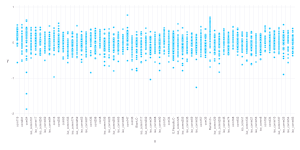

In [16]:
plot(x = disa.CommunityID, y = disa.deg_vs_blank, Geom.point)